In [51]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
import astropy.units as units
from tqdm import tqdm
import glob, os

import sys
sys.path.append("../scripts")
from forward_model import make_wcs
# from preprocessing import *

import matplotlib.pylab as pylab
plt.style.use("science")
params = {
         'axes.labelsize': 20,
         'axes.titlesize': 25,
         'ytick.labelsize' :20,
         'xtick.labelsize' :20,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "k",
         'ytick.labelcolor' : "k",
         'xtick.labelcolor' : "k",
         }
pylab.rcParams.update(params)


# Run this after running aligning_smacs_targets_drizzlepac since we update the WCS there

In [17]:
def align_wcs(wcs, shift_x, shift_y, theta):
    """
    This method takes in a WCS and applies a shift and rotation to its coordinates. This is
    useful when we align the cutouts and fit the shift and orientation so that exposures match
    when we drizzle. 
    """
    hdr = wcs.to_header(True) # True makes it so that we have the SIP coefficients

    pc = wcs.pixel_scale_matrix
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta), np.cos(theta)]])
    
    new_pc = rotation @ pc
    hdr["PC1_1"] = new_pc[0, 0]
    hdr["PC1_2"] = new_pc[0, 1]
    hdr["PC2_1"] = new_pc[1, 0]
    hdr["PC2_2"] = new_pc[1, 1]
    hdr["CRVAL1"] = hdr["CRVAL1"] + shift_y / 3600 # arcsec to deg
    hdr["CRVAL2"] = hdr["CRVAL2"] + shift_x / 3600
    hdr["CDELT1"] = 1
    hdr["CDELT2"] = 1
    # make a new wcs based on shift and rotation of the model
    new_wcs = WCS(hdr)
    return new_wcs


def save_cutout(
        output_path: str,
        pixels, 
        flc_or_flt_path: str, 
        coordinate: SkyCoord, 
        drz_path=None, 
        ver=1,
        shift_x:float=0.,
        shift_y:float=0.,
        theta:float=0.,
        flux_smaller_than=0.35, # Used to compute statistics
        verbose=0,
        overwrite=False
        ):
    """
    ver: The version of the SCI path. For HST, ver=1 points to CCDCHIP 2 and ver=2 points to CCDCHIP 1
    
    For each flc or flt paths, make a cutout and save the relevant information (SIP distortion, HDRLET etc.) 
    in each fits file to reconstruct the WCS correctly in inference time. 
    
    Our convention will be to save a cutout per flc. The script will injest each cutouts separately.

    I also defined shift_x, shift_y and theta such that an alignement solution can be provided (see notebooks aligning_smacs_targets).
    """
    data = fits.open(flc_or_flt_path)
    hdul = []
    hdul.append(fits.PrimaryHDU(header=data[0].header))
    
    # Make science cutout
    header = data["SCI", ver].header
    image = data["SCI", ver].data
    if data["SCI", ver].header["BUNIT"] != "ELECTRONS":
        print("Data units not in electrons count, exposure time will not be used to normalize the data")
        exptime = 1
    else:
        try:
            exptime = data[0].header["EXPTIME"]
        except KeyError as e:
            # For JWST, they changed the key to effective exposure time in i2d fits files
            exptime = data[0].header["EFFEXPTM"]
    # Important to use the active WCS to get the cutout, then correct cutout wcs with alignment solution
    wcs = WCS(header, data) 
    cutout = Cutout2D(image, coordinate, pixels, wcs=wcs)
    aligned_wcs = align_wcs(cutout.wcs, shift_x, shift_y, theta)

    if drz_path is not None:
        drz_data = fits.open(drz_path)
        drz_header = drz_data["SCI"].header
        drz_cutout = Cutout2D(drz_data["SCI"].data, coordinate, pixels, wcs=WCS(drz_header))
        drz_header.update(drz_cutout.wcs.to_header())
        drz = fits.ImageHDU(drz_cutout.data, name="DRZ", header=header)
        hdul.append(drz)
   
    temp = image.ravel() / exptime
    dark_sky = temp[(temp > 0) & (temp < flux_smaller_than)]
    three_sigma = np.quantile(dark_sky, 0.997)
    two_sigma = np.quantile(dark_sky, 0.95)
    dark_sky_mode = np.quantile(dark_sky, 0.5)
    if verbose:
        print(f"Measured dark sky flux = {dark_sky_mode:.2e} electrons/s")
   
    if verbose:
        plt.figure()
        plt.title(flc_or_flt_path, fontsize=15)
        plt.hist(dark_sky, bins=100)
        plt.annotate(r"Dark sky flux = %.2e $e^{-}/s$" % dark_sky_mode, xy=(0.01, 0.8), xycoords="axes fraction")
        plt.annotate(r"Dark sky $3\sigma$ = %.2e $e^{-}/s$" % three_sigma, xy=(0.01, 0.7), xycoords="axes fraction")
        plt.annotate(r"Dark sky $2\sigma$ = %.2e $e^{-}/s$" % two_sigma, xy=(0.01, 0.6), xycoords="axes fraction")

        # plt.xlim(-0.1)
        plt.xlabel(r"$e^{-}/s$")
        plt.ylabel("Count")
        plt.axvline(np.mean(dark_sky_mode), color="k", ls="--");
        plt.show()
    
    # pam = pamutils.pam_from_wcs(cutout.wcs) # pixel area map reads from distortion table coefficients in fits file
    wcs_hdr = aligned_wcs.to_header(True) # True saves the SIP distortions coefficients
    # Make sure to tell WCS we are using SIP distortions, otherwise it complains endlessly
    header.update(wcs_hdr)
    header["DARKSKY"] = dark_sky_mode
    if verbose:
        print("Applying PAM, dividing by EXPTIME and subtracting dark sky mode")
    # hdul.append(fits.ImageHDU(cutout.data * pam / exptime - dark_sky_mode, name="SCI", header=header))
    hdul.append(fits.ImageHDU(cutout.data / exptime - dark_sky_mode, name="SCI", header=header))

    
    distortion_papers = []
    for entry in data:
        if entry.name in ["D2IMARR", "WCSDVARR"]:
            distortion_papers.append(entry)
    hdul.extend(distortion_papers)
    hdul_obj = fits.HDUList(hdul)
    hdul_obj.writeto(output_path, overwrite=overwrite)
    return hdul_obj, data, cutout


In [18]:
from scipy.interpolate import interpn
from matplotlib.colors import Normalize
import matplotlib.cm as cm


def density_scatter(points, fig=None, ax=None, sort=True, bins=20, cmap="magma", norm=None, ticks=None, colorbar=False, **kwargs):
    """
    Scatter plot colored by 2d histogram
    """
    x = points[:, 0]
    y = points[:, 1]
    if ax is None:
        fig, ax = plt.subplots()
    data, x_edges, y_edges = np.histogram2d(x, y, bins=bins, density=True)
    x_bins = 0.5 * (x_edges[1:] + x_edges[:-1])
    y_bins = 0.5 * (y_edges[1:] + y_edges[:-1])
    z = interpn((x_bins, y_bins), data, np.vstack([x, y]).T, method="splinef2d", bounds_error=False)
    z[np.where(np.isnan(z))] = 0.0
    # Sort the points by density, so that the densest points are plotted last
    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    if norm is None:
        norm = Normalize(vmin=z.min(), vmax=z.max())
    ax.scatter(x, y, c=z, cmap=cmap, norm=norm, **kwargs)
    if fig is not None:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        box = ax.get_position()
        cax = plt.axes([box.x0*1.01 + box.width * 1.05, box.y0, 0.02, box.height])
        fig.colorbar(sm, cax=cax, ticks=ticks)
        cax.set_ylabel('Density')
    return ax


In [19]:
def interpolate(image, x, y, zero_fill=True):
    """
    Interpolation function, without a batch size. To make it batched, used vmap from functorch.
    """
    H, W = image.shape
    x = x.flatten()
    y = y.flatten()
    idxs_out_of_bounds = (y < 0) | (y > W-1) | (x < 0) | (x > W-1)
    x0 = np.floor(x).astype(np.int32)
    x1 = x0 + 1
    y0 = np.floor(y).astype(np.int32)
    y1 = y0 + 1

    x0 = np.clip(x0, 0, W - 1)
    x1 = np.clip(x1, 0, W - 1)
    y0 = np.clip(y0, 0, H - 1)
    y1 = np.clip(y1, 0, H - 1)
    x = np.clip(x, 0, W - 1)
    y = np.clip(y, 0, H - 1)

    Ia = image[x0, y0]
    Ib = image[x0, y1]
    Ic = image[x1, y0]
    Id = image[x1, y1]

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    result = (wa * Ia + wb * Ib + wc * Ic + wd * Id)
    result[idxs_out_of_bounds] = 0

    return result


In [20]:
data_dir = "../data/SMACSJ0723/JWST/"
cal_paths = glob.glob(data_dir + "*cal.fits")
i2d_paths = glob.glob(data_dir + "*i2d.fits")


filters = ["F115W", "F150W"]
# Cannot sort the calibration file this way since filter is not in the title
# cal_paths_sorted = {
#     "F150W": [p for p in cal_paths if "f150w" in p],
#     "F115W": [p for p in cal_paths if "f115w" in p],
# }
i2d_paths_sorted = {
    "F150W": [p for p in i2d_paths if "f150w" in p],
    "F115W": [p for p in i2d_paths if "f115w" in p],
}

In [21]:
coord1 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(units.hourangle, units.deg))
coord3 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(units.hourangle, units.deg))
coord = coord2


data = np.load("../results/smacs2_temp_solutions_vp_probes_prior.npz")
# data = np.load("../results/smacs2_temp_solutions_vp_skirt_prior.npz")

post_samples = data["sol"]
# observations = data["observations"]
y_hat = data["y_hat"] # reconstructions

In [22]:
# # Make shifted coordinate to correct for F150W bad WCS
# shift_ra =  0.1 / 3600 * units.deg # fitted by eye unfortunately
# shift_dec = 0.35 / 3600 * units.deg

# coords = [coord1, coord2, coord3]#, coord4]
# f150w_coords = [SkyCoord(c.ra + shift_ra, c.dec + shift_dec) for c in coords]

# shift_ra =  -0.35 / 3600 * units.deg # fitted by eye unfortunately
# shift_dec = 0.15 / 3600 * units.deg
# f115w_coords = [SkyCoord(c.ra + shift_ra, c.dec + shift_dec) for c in coords]

In [23]:
# targets = list(range(3))
# jwst_cutouts = {k: {i: [] for i in targets} for k in filters}
# hdul = {k: [] for k in filters}
# for target in targets:
#     for f in filters:
#         paths = i2d_paths_sorted[f]
#         for i, path in enumerate(paths):
#             print(f, path)
#             hdul_obj, data, cutout = save_cutout(f"../data/smacs_jwst_i2d_target{target}_{f}.fits",
#                                             pixels=64 if f=="F115W" else 128, # double resolution with F150W
#                                             flc_or_flt_path=path,
#                                             coordinate=f115w_coords[target] if f == "F115W" else f150w_coords[target],
#                                             flux_smaller_than=0.25,
#                                             overwrite=True,
#                                             # verbose=1, # fix units of plot to be units read in fits file
#                                             ver=1
#                                             )
#             jwst_cutouts[f][target].append(cutout)

F115W ../data/SMACSJ0723/JWST/jw02736-o003_t001_niriss_clear-f115w_i2d.fits
Data units not in electrons count, exposure time will not be used to normalize the data
F150W ../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits
Data units not in electrons count, exposure time will not be used to normalize the data


Set DATE-AVG to '2022-06-17T09:06:06.285' from MJD-AVG.
Set DATE-END to '2022-06-17T10:01:37.405' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-07T04:05:22.536' from MJD-AVG.
Set DATE-END to '2022-06-07T05:14:03.242' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


F115W ../data/SMACSJ0723/JWST/jw02736-o003_t001_niriss_clear-f115w_i2d.fits
Data units not in electrons count, exposure time will not be used to normalize the data
F150W ../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits
Data units not in electrons count, exposure time will not be used to normalize the data


Set DATE-AVG to '2022-06-17T09:06:06.285' from MJD-AVG.
Set DATE-END to '2022-06-17T10:01:37.405' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-07T04:05:22.536' from MJD-AVG.
Set DATE-END to '2022-06-07T05:14:03.242' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


F115W ../data/SMACSJ0723/JWST/jw02736-o003_t001_niriss_clear-f115w_i2d.fits
Data units not in electrons count, exposure time will not be used to normalize the data
F150W ../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits
Data units not in electrons count, exposure time will not be used to normalize the data


Set DATE-AVG to '2022-06-17T09:06:06.285' from MJD-AVG.
Set DATE-END to '2022-06-17T10:01:37.405' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-07T04:05:22.536' from MJD-AVG.
Set DATE-END to '2022-06-07T05:14:03.242' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [24]:
target = 2
FILTER = "F105W"
paths = glob.glob(f"../data/smacs*target{target}*{FILTER.upper()}*.fits")
data = []
for p in paths:
    data.append(fits.open(p))
    
jwst_cutout = fits.open("../data/smacs_jwst_i2d_target2_F115W.fits")
# jwst_cutout = fits.open("../data/smacs_jwst_i2d_target2_F150W.fits")

jwst_wcs = WCS(jwst_cutout[1].header)
jwst_img = jwst_cutout[1].data

Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


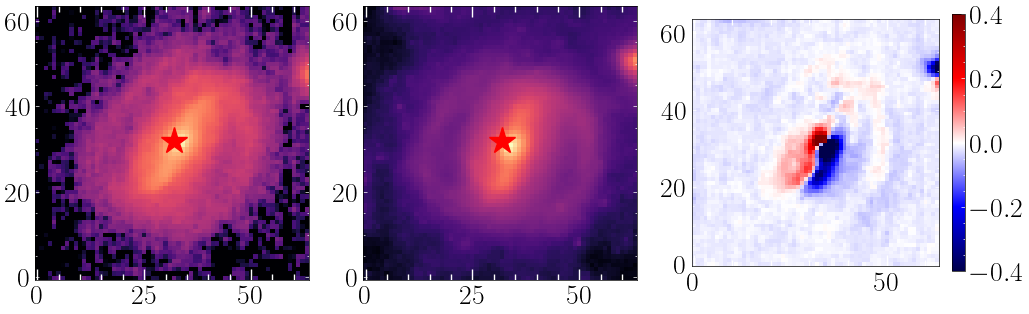

In [25]:
from torch.nn.functional import avg_pool2d
import torch
img = avg_pool2d(torch.tensor(np.rot90(post_samples[1, 0], k=-1).copy()).view(1, 1, 256, 256), 4).numpy().squeeze()
img.shape


fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].plot([32], [32], "r*", markersize=20)
axs[0].imshow(jwst_img, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, clip=True), origin="lower")
axs[1].plot([32], [32], "r*", markersize=20)
axs[1].imshow(img, cmap="magma", norm=plt.cm.colors.LogNorm(), origin="lower")
im = axs[2].imshow(jwst_img - 0.3*img, cmap="seismic", vmin=-0.4, vmax=0.4, origin="lower")
plt.colorbar(im, ax=axs[2], fraction=0.047)

In [26]:
0.13/8 * 256

4.16

In [27]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(jwst_wcs) * 3600 # we get a rough estimate of the size of a pixel

print(pixel_scale_x * jwst_img.shape[1])
0.13/8 * 256 / pixel_scale_y #* jwst_img.shape[0]

4.196319568224169


63.446073558378416

In [28]:
wcs_ref = make_wcs(coord2, orientation=90-24.42, pixels=64, pixel_size=0.13/8 * units.arcsec)

In [29]:
wcs_ref

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 110.8420020833333  -73.45682638888889  
CRPIX : 31.0  31.0  
PC1_1 PC1_2  : 1.8661422957704e-06  4.11007370167145e-06  
PC2_1 PC2_2  : 4.11007370167145e-06  -1.8661422957704e-06  
CDELT : 1.0  1.0  
NAXIS : 64  64

In [30]:
jwst_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 110.82713188683  -73.454626276413  
CRPIX : -537.93176223267  939.32234239338  
PC1_1 PC1_2  : 1.6582445961612e-05  7.5327863063627e-06  
PC2_1 PC2_2  : 7.5327863063627e-06  -1.6582445961611e-05  
CDELT : 1.0  1.0  
NAXIS : 64  64

In [50]:
wcs_ref.pixel_to_world(31, 31)

<SkyCoord (ICRS): (ra, dec) in deg
    (110.84202307, -73.45682414)>

In [49]:
jwst_wcs.pixel_to_world(-128, 0)

<SkyCoord (ICRS): (ra, dec) in deg
    (110.82624118, -73.43597113)>

In [39]:
observation = img
pixels = img.shape[0]

def forward(shift_x, shift_y, theta):
    data = fits.open(flc_or_flt_path)
    hdul = []
    hdul.append(fits.PrimaryHDU(header=data[0].header))
    
    # Make science cutout
    header = data["SCI", ver].header
    image = data["SCI", ver].data
    if data["SCI", ver].header["BUNIT"] != "ELECTRONS":
        print("Data units not in electrons count, exposure time will not be used to normalize the data")
        exptime = 1
    else:
        try:
            exptime = data[0].header["EXPTIME"]
        except KeyError as e:
            # For JWST, they changed the key to effective exposure time in i2d fits files
            exptime = data[0].header["EFFEXPTM"]
    # Important to use the active WCS to get the cutout, then correct cutout wcs with alignment solution
    wcs = WCS(header, data) 
    cutout = Cutout2D(image, coordinate, pixels, wcs=wcs)
    aligned_wcs = align_wcs(cutout.wcs, shift_x, shift_y, theta)

    if drz_path is not None:
        drz_data = fits.open(drz_path)
        drz_header = drz_data["SCI"].header
        drz_cutout = Cutout2D(drz_data["SCI"].data, coordinate, pixels, wcs=WCS(drz_header))
        drz_header.update(drz_cutout.wcs.to_header())
        drz = fits.ImageHDU(drz_cutout.data, name="DRZ", header=header)
        hdul.append(drz)
   
    temp = image.ravel() / exptime
    dark_sky = temp[(temp > 0) & (temp < flux_smaller_than)]
    three_sigma = np.quantile(dark_sky, 0.997)
    two_sigma = np.quantile(dark_sky, 0.95)
    dark_sky_mode = np.quantile(dark_sky, 0.5)
    if verbose:
        print(f"Measured dark sky flux = {dark_sky_mode:.2e} electrons/s")
   
    if verbose:
        plt.figure()
        plt.title(flc_or_flt_path, fontsize=15)
        plt.hist(dark_sky, bins=100)
        plt.annotate(r"Dark sky flux = %.2e $e^{-}/s$" % dark_sky_mode, xy=(0.01, 0.8), xycoords="axes fraction")
        plt.annotate(r"Dark sky $3\sigma$ = %.2e $e^{-}/s$" % three_sigma, xy=(0.01, 0.7), xycoords="axes fraction")
        plt.annotate(r"Dark sky $2\sigma$ = %.2e $e^{-}/s$" % two_sigma, xy=(0.01, 0.6), xycoords="axes fraction")

        # plt.xlim(-0.1)
        plt.xlabel(r"$e^{-}/s$")
        plt.ylabel("Count")
        plt.axvline(np.mean(dark_sky_mode), color="k", ls="--");
        plt.show()
    
    # pam = pamutils.pam_from_wcs(cutout.wcs) # pixel area map reads from distortion table coefficients in fits file
    wcs_hdr = aligned_wcs.to_header(True) # True saves the SIP distortions coefficients
    # Make sure to tell WCS we are using SIP distortions, otherwise it complains endlessly
    header.update(wcs_hdr)
    header["DARKSKY"] = dark_sky_mode
    if verbose:
        print("Applying PAM, dividing by EXPTIME and subtracting dark sky mode")
    # hdul.append(fits.ImageHDU(cutout.data * pam / exptime - dark_sky_mode, name="SCI", header=header))
    hdul.append(fits.ImageHDU(cutout.data / exptime - dark_sky_mode, name="SCI", header=header))

    
    distortion_papers = []
    for entry in data:
        if entry.name in ["D2IMARR", "WCSDVARR"]:
            distortion_papers.append(entry)
    hdul.extend(distortion_papers)
    hdul_obj = fits.HDUList(hdul)
    hdul_obj.writeto(output_path, overwrite=overwrite)
    return hdul_obj, data, cutout

    # return y.reshape(*wcs_ref.pixel_shape)

std = 0.1
def chi_squared(shift_x, shift_y, theta):
    return np.sum(((img - forward(shift_x, shift_y, theta)))**2 / std**2)


In [40]:
forward(0, 0, 0)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 110.82713188683  -73.454626276413  
CRPIX : -537.93176223267  939.32234239338  
PC1_1 PC1_2  : 1.6582445961612e-05  7.5327863063627e-06  
PC2_1 PC2_2  : 7.5327863063627e-06  -1.6582445961611e-05  
CDELT : 1.0  1.0  
NAXIS : 0  0
<SkyCoord (ICRS): (ra, dec) in deg
    [[(110.84137243, -73.45689371), (110.84138686, -73.45689557),
      (110.8414013 , -73.45689744), ..., (110.84225294, -73.45700754),
      (110.84226738, -73.45700941), (110.84228181, -73.45701127)],
     [(110.84137898, -73.4568896 ), (110.84139341, -73.45689146),
      (110.84140785, -73.45689333), ..., (110.8422595 , -73.45700343),
      (110.84227393, -73.4570053 ), (110.84228836, -73.45700716)],
     [(110.84138553, -73.45688549), (110.84139997, -73.45688735),
      (110.8414144 , -73.45688922), ..., (110.84226605, -73.45699932),
      (110.84228048, -73.45700119), (110.84229492, -73.45700305)],
     ...,
     [(110.84177222, -73.45664299), (

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [55]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(jwst_wcs) * 3600 # we get a rough estimate of the size of a pixel

N_shift = 5 # We search N^3 points for each cutout! So be careful with this number
N_theta = 5 # also, make the number odd so they include 0

# Search radius is defined here
npix = 1
dx = 2*npix * pixel_scale_x / N_shift
dy = 2*npix * pixel_scale_x / N_shift
theta_max = 0.001

# Make an initial search radius
shift_x_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_x
shift_y_grid = np.linspace(-1, 1, N_shift) * npix * pixel_scale_y
theta_grid = np.linspace(-1, 1, N_theta) * theta_max # careful, chi sq is very senstive to a global rotation of the coordinate system

i_ref = 1
chi_sq1 = np.zeros((N_shift, N_shift, N_theta))
for j, shift_x in enumerate(shift_x_grid):
    for k, shift_y in enumerate(shift_y_grid):
        for ell, theta in enumerate(theta_grid):
            chi_sq1[j, k, ell] = chi_squared(shift_x, shift_y, theta) # Self alignement is interesting to test if the forward model is good

Shift x: -0.06556749325350264 | Shift y: -0.06556749325349935 | theta: -0.001 | chi sq 32649.0805190933


Text(0.5, 0.98, 'Alignment $\\chi^2$ surface')

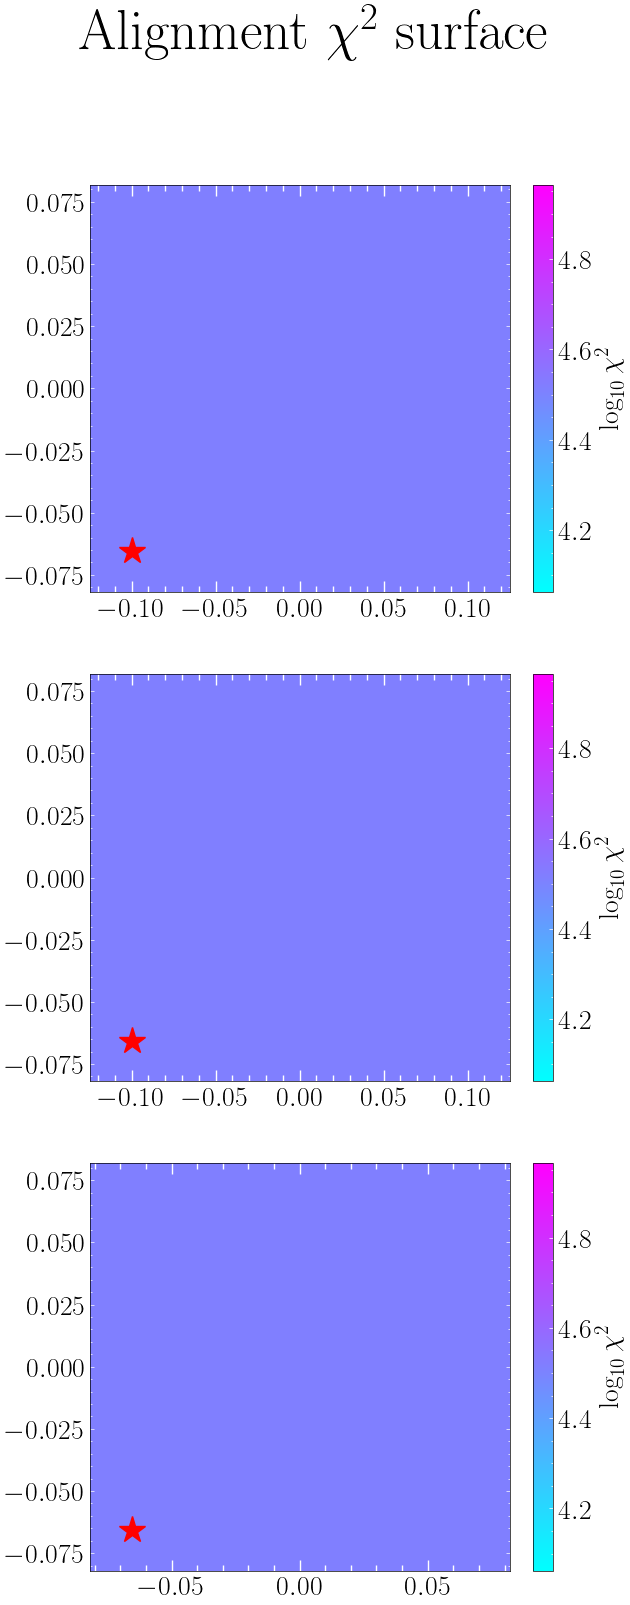

In [56]:
fig, axs = plt.subplots(3, 1, figsize=(6, 18), sharey=True)
for i in range(3):
    index = 0
    ll = chi_sq1
    # We slice the likelihood at the dimension where the minimum is
    ii, jj, kk = np.unravel_index(np.argmin(ll), (N_shift, N_shift, N_theta))
    if i == 0:
        print(f"Shift x: {shift_x_grid[ii]} | Shift y: {shift_y_grid[jj]} | theta: {theta_grid[kk]} | chi sq {ll[ii, jj, kk]}")
    if i == 0:
        ll = ll[:, jj]
        x, y = np.meshgrid(theta_grid * 100, shift_x_grid)
        axs[i].plot(theta_grid[kk]*100, shift_x_grid[ii], "r*", markersize=20)

    elif i == 1:
        ll = ll[ii]
        x, y = np.meshgrid(theta_grid * 100, shift_y_grid)
        axs[i].plot(theta_grid[kk]*100, shift_y_grid[jj], "r*", markersize=20)

    elif i == 2:
        ll = ll[..., kk]
        x, y = np.meshgrid(shift_x_grid, shift_y_grid, indexing="ij")
        axs[i].plot(shift_x_grid[ii], shift_y_grid[jj], "r*", markersize=20)
    im = axs[i].pcolormesh(x, y, np.log10(ll), cmap="cool")
    # index += 1
    # if j == len(wcs_list) - 2:
    plt.colorbar(im, ax=axs[i], fraction=0.047, label=r"$\log_{10} \chi^2$")

fig.suptitle(rf"Alignment $\chi^2$ surface", fontsize=40)

In [ ]:
fig, axs = plt.subplots(3, len(wcs_list)-1, figsize=(6 * len(wcs_list)-6, 18), sharey=True)


index = 0
for i in tqdm(range(len(wcs_list))):
    if i == i_ref:
        continue
    ll = np.array(chi_sq1[i])
    ii, jj, kk = np.unravel_index(np.argmin(ll), (N_shift, N_shift, N_theta))
    y = forward(shift_x_grid[ii], shift_y_grid[jj], theta_grid[kk], i, i_ref)
    y_nothing = forward(0, 0, 0, i, i_ref)
    
    axs[0, index].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, index].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    axs[2, index].imshow(observations[i_ref] - y_nothing, cmap="seismic", vmin=-1, vmax=1)
    index += 1
        
for i in range(3):
    for j in range(len(wcs_list)-1):
        axs[i, j].axis("off")